## Local Inference on GPU
Model page: https://huggingface.co/lxyuan/distilbert-base-multilingual-cased-sentiments-student

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/lxyuan/distilbert-base-multilingual-cased-sentiments-student)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [1]:
!pip install -U transformers
!pip install datasets
!pip install pandas
!pip install scikit-learn
!pip install openpyxl
!pip install torch

In [2]:
import pandas as pd

df = pd.read_excel("DataGabungan.xlsx")

df.head()

,TOPIK,Username Posting owner,Link post IG,Username komentar,Isi komentar,Sentimen
0,Tentara Nasional Indonesia (TNI) berniat menel...,tempodotco,https://www.instagram.com/p/DLPF7LDs29b/,halidi.iy,Guaaaaa,-1
1,Tentara Nasional Indonesia (TNI) berniat menel...,tempodotco,https://www.instagram.com/p/DLPF7LDs29b/,sagi.saputra_,"Lucu, lalu setelah tau dalangnya, mau diapain??",-1
2,Tentara Nasional Indonesia (TNI) berniat menel...,tempodotco,https://www.instagram.com/p/DLPF7LDs29b/,lzrd.nzr,Maksudnya ga boleh nolak?,-1
3,Tentara Nasional Indonesia (TNI) berniat menel...,tempodotco,https://www.instagram.com/p/DLPF7LDs29b/,febrisheget,"Saya dalangnya pak, sini dah ngopi. saya cerit...",0
4,Tentara Nasional Indonesia (TNI) berniat menel...,tempodotco,https://www.instagram.com/p/DLPF7LDs29b/,setyaryantio,Yang lain siap siap ww3 yang disini masih ngur...,-1


In [3]:
df = df[["Isi komentar", "Sentimen"]]

df = df.rename(columns={
    "Isi komentar": "text",
    "Sentimen": "label"
})

df.head()


,text,label
0,Guaaaaa,-1
1,"Lucu, lalu setelah tau dalangnya, mau diapain??",-1
2,Maksudnya ga boleh nolak?,-1
3,"Saya dalangnya pak, sini dah ngopi. saya cerit...",0
4,Yang lain siap siap ww3 yang disini masih ngur...,-1


In [4]:
df["label"].value_counts()

,count
label,
0,7424
-1,6224
1,3309


In [5]:
# Gunakan .replace() lebih aman daripada .map() untuk menghindari nilai NaN
df["label"] = df["label"].replace({
    -1: 0,
    0: 1,
    1: 2
})

In [6]:
df["label"].value_counts()

,count
label,
1,7424
0,6224
2,3309


In [8]:
# CELL BARU - Taruh setelah CELL 6 (sebelum CELL 7)
# Data Augmentation untuk kelas positif (DIPERBAIKI)

import random
from tqdm import tqdm

def augment_text(text, label):
    """Simple data augmentation untuk teks Bahasa Indonesia"""

    # PASTIKAN TEXT ADALAH STRING
    text = str(text)

    augmented = [text]

    # Hanya augment untuk kelas minoritas (Positif/label=2)
    if label == 2:
        # 1. Tambahkan kata positif
        positive_words = ["👍", "sangat", "luar biasa", "keren", "mantap", "best", "bagus"]
        for word in positive_words:
            augmented.append(f"{word} {text}")
            augmented.append(f"{text} {word}")

        # 2. Hapus kata negatif jika ada (pastikan text adalah string)
        negative_words = ["tidak", "kurang", "buruk", "jelek", "parah"]
        new_text = text
        for neg in negative_words:
            new_text = new_text.replace(neg, "")
        if new_text != text and len(new_text.strip()) > 5:
            augmented.append(new_text)

    return augmented[:3]  # Batasi augmentasi

# Pastikan kolom text adalah string
print("Memastikan semua text dalam format string...")
df["text"] = df["text"].astype(str)
print("Selesai.")

# Apply augmentasi
print("Melakukan augmentasi data...")
augmented_texts = []
augmented_labels = []

for text, label in tqdm(zip(df["text"], df["label"]), total=len(df)):
    aug_texts = augment_text(text, label)
    augmented_texts.extend(aug_texts)
    augmented_labels.extend([label] * len(aug_texts))

# Buat dataframe baru dengan data yang sudah diaugmentasi
df_augmented = pd.DataFrame({
    "text": augmented_texts,
    "label": augmented_labels
})

print(f"\n📊 Hasil Augmentasi:")
print(f"Data asli: {len(df)} baris")
print(f"Data setelah augmentasi: {len(df_augmented)} baris")
print(f"Peningkatan: {len(df_augmented) - len(df)} baris ({((len(df_augmented)-len(df))/len(df)*100):.1f}%)")

# Cek distribusi baru
print("\nDistribusi label setelah augmentasi:")
print(df_augmented["label"].value_counts())

# Gunakan df_augmented untuk training selanjutnya
df = df_augmented

Memastikan semua text dalam format string...
Selesai.
Melakukan augmentasi data...


100%|██████████| 16957/16957 [00:00<00:00, 570690.01it/s]


📊 Hasil Augmentasi:
Data asli: 16957 baris
Data setelah augmentasi: 23575 baris
Peningkatan: 6618 baris (39.0%)

Distribusi label setelah augmentasi:
label
2    9927
1    7424
0    6224
Name: count, dtype: int64


In [9]:
# CELL BARU - Taruh setelah CELL 6 (sebelum CELL 7)
# Data Augmentation untuk kelas positif

import random
from tqdm import tqdm

def augment_text(text, label):
    """Simple data augmentation untuk teks Bahasa Indonesia"""
    augmented = [text]

    # Hanya augment untuk kelas minoritas (Positif/label=2)
    if label == 2:
        # 1. Tambahkan kata positif
        positive_words = ["👍", "sangat", "luar biasa", "keren", "mantap", "best"]
        for word in positive_words:
            augmented.append(f"{word} {text}")
            augmented.append(f"{text} {word}")

        # 2. Hapus kata negatif jika ada
        negative_words = ["tidak", "kurang", "buruk", "jelek", "parah"]
        new_text = text
        for neg in negative_words:
            new_text = new_text.replace(neg, "")
        if new_text != text and len(new_text.strip()) > 5:
            augmented.append(new_text)

    return augmented[:3]  # Batasi augmentasi

# Apply augmentasi
print("Melakukan augmentasi data...")
augmented_texts = []
augmented_labels = []

for text, label in tqdm(zip(df["text"], df["label"]), total=len(df)):
    aug_texts = augment_text(text, label)
    augmented_texts.extend(aug_texts)
    augmented_labels.extend([label] * len(aug_texts))

# Buat dataframe baru dengan data yang sudah diaugmentasi
df_augmented = pd.DataFrame({
    "text": augmented_texts,
    "label": augmented_labels
})

print(f"Data asli: {len(df)} baris")
print(f"Data setelah augmentasi: {len(df_augmented)} baris")

# Gunakan df_augmented untuk training selanjutnya
df = df_augmented
df["label"].value_counts()  # Cek distribusi baru

Melakukan augmentasi data...


100%|██████████| 23575/23575 [00:00<00:00, 410113.05it/s]

Data asli: 23575 baris
Data setelah augmentasi: 43429 baris


,count
label,
2,29781
1,7424
0,6224


In [10]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained(
    "lxyuan/distilbert-base-multilingual-cased-sentiments-student"
)

model = AutoModelForSequenceClassification.from_pretrained(
    "lxyuan/distilbert-base-multilingual-cased-sentiments-student",
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [11]:
df = df.dropna(subset=["text"])
df = df[df["text"].str.strip() != ""]



In [12]:
df["text"] = df["text"].astype(str)

df.head()

,text,label
0,Guaaaaa,0
1,"Lucu, lalu setelah tau dalangnya, mau diapain??",0
2,Maksudnya ga boleh nolak?,0
3,"Saya dalangnya pak, sini dah ngopi. saya cerit...",1
4,Yang lain siap siap ww3 yang disini masih ngur...,0


In [23]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42
)

In [24]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

In [25]:
import torch

class SentimentDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

In [26]:
print(f"Total data: {len(df)}")
print(f"Train: {len(train_texts)}")
print(f"Test: {len(test_texts)}")

Total data: 43429
Train: 34743
Test: 8686


In [27]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    warmup_ratio=0.1,
    weight_decay=0.05,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    lr_scheduler_type="cosine",
    save_total_limit=2,
    logging_steps=100,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [28]:
# Tambahkan cell ini sebelum WeightedTrainer
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_labels
)
print(f"Class weights: {class_weights}")

Class weights: [2.3278392  1.95525916 0.48567834]


In [29]:
import torch
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        weights = torch.tensor(class_weights, dtype=torch.float).to(logits.device)
        loss_fn = torch.nn.CrossEntropyLoss(weight=weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [30]:
from transformers import EarlyStoppingCallback

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]  # Early stopping di sini
)

# Mulai training
trainer.train()

# Simpan model terbaik
trainer.save_model("./best_model")
tokenizer.save_pretrained("./best_model")

Epoch,Training Loss,Validation Loss
1,0.535823,0.524147
2,0.411831,0.492469
3,0.286774,0.613147


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./best_model/tokenizer_config.json', './best_model/tokenizer.json')

In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

# Classification report
print("=== Classification Report ===")
print(classification_report(test_labels, preds, target_names=["Negatif", "Netral", "Positif"]))


=== Classification Report ===
              precision    recall  f1-score   support

     Negatif       0.59      0.74      0.66      1249
      Netral       0.63      0.73      0.67      1501
     Positif       0.98      0.90      0.94      5936

    accuracy                           0.84      8686
   macro avg       0.74      0.79      0.76      8686
weighted avg       0.87      0.84      0.85      8686



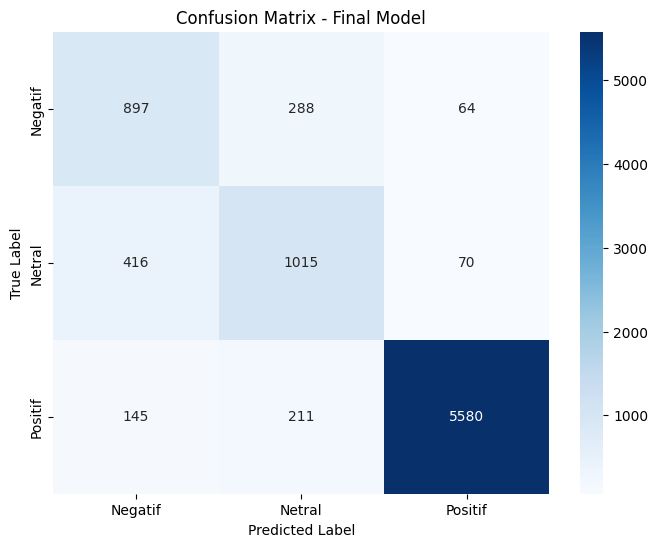

Negatif: TP=897, TN=6876, FP=561, FN=352
Netral: TP=1015, TN=6686, FP=499, FN=486
Positif: TP=5580, TN=2616, FP=134, FN=356


In [36]:
# Cukup gunakan final_preds saja
cm_final = confusion_matrix(test_labels, final_preds)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix - Final Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print metrics
for i, label in enumerate(["Negatif", "Netral", "Positif"]):
    TP = cm_final[i, i]
    FP = cm_final[:, i].sum() - TP
    FN = cm_final[i, :].sum() - TP
    TN = cm_final.sum() - TP - FP - FN
    print(f"{label}: TP={TP}, TN={TN}, FP={FP}, FN={FN}")